# Анализ оттока клиентов банка

# Оглавление
1. [Описание проекта](#cell1)
2. [Выгрузка данных](#cell2)
3. [Предобработка данных](#cell3)
4. [Исследовательский анализ данных](#cell4)
   
    4.1 [Расчет корреляции признаков](#cell4.1)
   
    4.2 [Анализ распределения признаков в разрезе оттока](#cell4.2)
   
    4.3 [Категоризация клиентов](#cell4.3)

   4.3.1 [Категоризация клиентов в зависимости от остатка средств на балансе](#cell4.3.1)
   
   4.3.2 [Категоризация клиентов в зависимости от возраста](#cell4.3.2)
   
   4.3.3 [Категоризация клиентов по score](#cell4.3.3)
   
   4.3.4 [Категоризация клиентов по уровню зарплаты](#cell4.3.4)
6. [Проверка гипотез](#cell5)
   
   5.1 [Гипотеза о разнице средних зарплат](#cell5.1)
   
   5.2 [Гипотеза о равенстве доли оттока у клиентов с разной зарплатой](#cell5.2)
7. [Сегментация клиентов](#cell6)

   6.1 [Приоритизация сегментов](#cell6.1)
       
8. [Сводный вывод по проекту](#cell7)

<a id="cell1"></a> 
## Описание проекта
**Цель проекта:**  проанализировать клиентов одного регионального банка,  выделить сегменты клиентов, которые наиболее склонны уходить из банка, чтобы предложить рекомендации по их удержанию.

**Задачи проекта:**
1. выгрузить данные и провести их предварительную обработку:
    - проверить корректность наименований столбцов
    - проверить корректность форматов данных, изменить при необходимости
    - проверить наличие явных  дубликатов строк 
    - классифицировать и обработать пропуски  
    - проверить наличие неявных дубликатов

2.	провести исследовательский анализ данных (EDA):
   
    - построить матрицу корреляций оттока с остальными признаками, выявить признаки, наиболее сильно влияющие на отток
    - сформировать портреты клиентов в разрезе оттока
    - проанализировать распределения признаков в разрезе оттока,
    - категорировать клиентов, выделить категории клиентов, более склонных к оттоку
      
  
3. проверить  статистические гипотезы:
    - гипотеза различия дохода между теми клиентами, которые ушли и теми, которые остались
    - гипотеза различия доли оттока у клиентов с зарплатой менее 100 тыс и более 100 тыс.
    
4. сегментировать клиентов по признакам, влияющим на отток, приоритизировать сегменты
5. сформулировать основные выводы по исследованию и разработать рекомендации по удержанию клиентов


<a id="cell2"></a> 
## Выгрузка данных

In [1]:
import pandas as pd 
import numpy as np 
from datetime import datetime
from matplotlib import pyplot as plt 
import seaborn as sns 

from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# выгрузка данных
try:
    df = pd.read_csv('/datasets/bank_scrooge.csv')
except: 
    df = pd.read_csv('bank_scrooge.csv')
df.head(10)

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1
5,202305,856.0,Рыбинск,М,56.0,4,863687.24,3,1,0,156619.80,0
6,177259,807.0,Ярославль,Ж,39.0,3,405042.44,3,0,1,103838.32,0
7,218868,825.0,Ярославль,Ж,38.0,4,458145.40,2,1,1,68085.48,0
8,211686,923.0,Ярославль,М,54.0,5,1206337.87,2,1,0,155371.79,0
9,133130,906.0,Ярославль,Ж,67.0,0,NaN,1,0,1,238055.53,0


<div style="border:solid blue 1px; padding: 10px">

**Вывод по разделу**: импортированы необходимые для работы библиотеки и выгружен датафрейм

<a id="cell3"></a> 
## Предобработка данных

In [3]:
# названия всех столбцов переводим в нижний регистр
df.columns = [x.lower() for x in df.columns]
df.head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   userid         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  est_salary     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


Все типы данных в столбцах корректны

In [5]:
# проверяем количество строк-дубликатов
print(df.duplicated().sum())

# проверяем дубликаты в конкретном столбце
df['userid'].duplicated().sum()

0


73

Явных дубликатов строк нет, в столбце userid есть повторяющиеся значения, выведем их все для проверки

In [6]:
# вывод всех дубликатов по userid
pd.set_option('display.max_rows', None) # вывод на экран всех строк датафрейма

df[df.duplicated(['userid'], keep=False)].sort_values(by='userid')

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1893,116540,883.0,Рыбинск,Ж,55.0,1,362756.49,3,0,1,175920.48,1
7694,116540,887.0,Ярославль,Ж,38.0,0,NaN,1,0,1,119247.61,0
7542,117943,880.0,Ярославль,Ж,40.0,0,NaN,1,1,0,137718.93,0
4866,117943,855.0,Рыбинск,Ж,32.0,6,1036832.93,4,1,1,107792.71,1
5896,120258,905.0,Ярославль,М,30.0,0,NaN,1,1,1,146427.96,0
5863,120258,908.0,Рыбинск,Ж,38.0,4,2213581.63,2,0,1,160327.77,1
1411,123461,829.0,Ярославль,Ж,59.0,0,96222.44,2,0,1,102771.55,1
8638,123461,934.0,Рыбинск,М,34.0,0,NaN,2,1,0,291619.27,0
8164,124450,859.0,Ярославль,Ж,38.0,6,516811.20,1,1,1,95144.63,1
9775,124450,758.0,Рыбинск,Ж,36.0,0,73574.07,2,0,1,79963.59,0


<div style="border:solid blue 1px; padding: 10px">
У 50 клиентов не уникальные userid, они дублируются, т.е. двум разным клиентам присвоен один и тот же userid. Есть закономерность: один из клиентов с дублирующимся userid - в Ярославском отделении, второй - в Рыбинском отделении. Можно предположить, что был технический баг. В данном случае дубликаты остаются, т.к. удаление приведет к потере клиентов, а идентификацию клиента можно проводить по совокупности других признаков

Проверка уникальных значений категориальных признаков для выявления неявных дубликатов

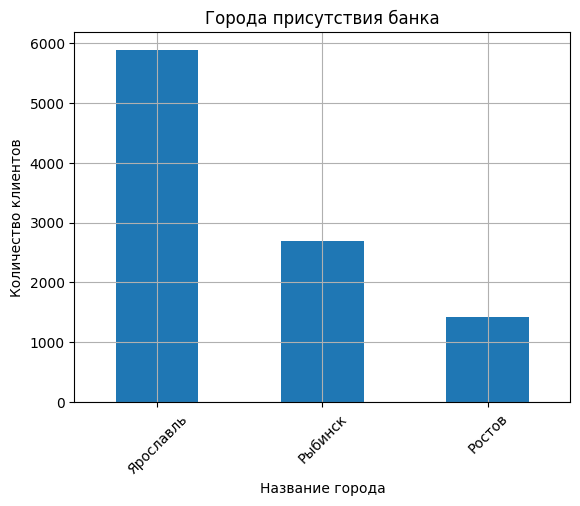

In [7]:
# проверяем уникальные значения столбца city
df['city'].value_counts().plot(
    kind = 'bar', 
    grid=True, 
    title = 'Города присутствия банка', 
    xlabel = 'Название города', 
    ylabel = 'Количество клиентов'
)
plt.xticks(rotation=45)
plt.show()

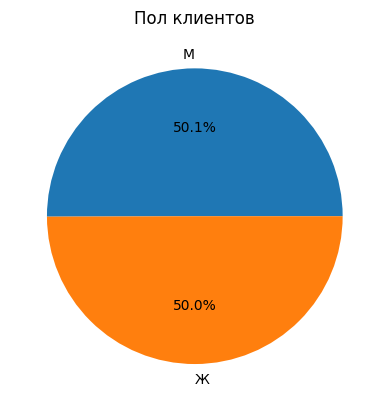

In [8]:
# прoверяем разделение клиентов по полу
df['gender'].value_counts().plot(
    kind = 'pie', 
    title = 'Пол клиентов', 
    autopct = "%.1f%%",
    ylabel= ""
)     
plt.show()

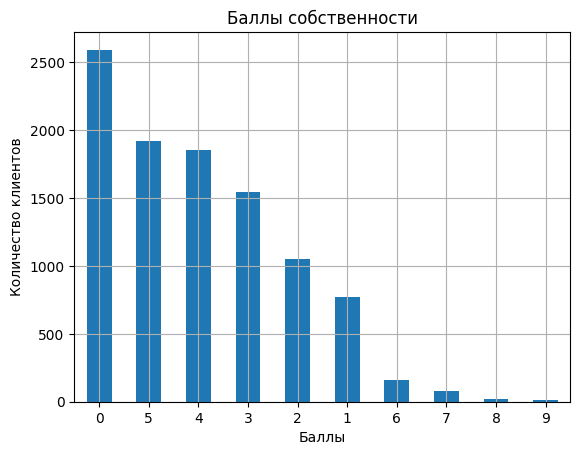

In [9]:
# прoверяем разделение клиентов по баллам собственности
df['equity'].value_counts().plot(
    kind = 'bar', 
    grid=True, 
    title = 'Баллы собственности', 
    xlabel = 'Баллы', 
    ylabel = 'Количество клиентов',
    
)
plt.xticks(rotation=360)
plt.show()

Проверка и обработка пропусков

In [10]:
# доля пропусков в столбцах
df.isna().sum()/len(df)

userid           0.0000
score            0.0000
city             0.0000
gender           0.0000
age              0.0026
equity           0.0000
balance          0.2295
products         0.0000
credit_card      0.0000
last_activity    0.0000
est_salary       0.0000
churn            0.0000
dtype: float64

<div style="border:solid blue 1px; padding: 10px">
Имеются пропуски в столбцах age и balance. Доля пропусков в столбце age незначительна (менее 1%). В столбце balance доля пропусков существенная (23%). Пропуски  будут классифицированы и обработаны на этапе EDA.  На данном этапе пропуски оставляем без изменений, т.к. удаление приведет к потери значительной части данных. 

In [11]:
# количество клиентов попавших (1) и не попавших (0) в отток
df['churn'].value_counts()

0    8180
1    1820
Name: churn, dtype: int64

<div style="border:solid blue 1px; padding: 10px">

Вывод по разделу:
- наименования столбцов приведены к нижнему регистру
- форматы всех данных корректны
- выявлены пропуски в столбцах age и balance, которые будут классифицированы и обработаны на этапе EDA. Пропусков в других столбцах нет 
- явные  дубликаты строк отсутствуют
- выявлено наличие дубликатов  клиентов по userid (у 50 клиентов дублируются userid), вероятная пречина - технический баг. Дубликаты оставлены, чтобы не потерять клиентов
- проверены уникальные значения категориальных признаков для выявления неявных дубликатов (дубликаты отсутствуют)
    

<a id="cell4"></a> 
## Исследовательский анализ данных (EDA)

<a id="cell4.1"></a> 
### Расчет корреляции признаков

In [12]:
# создадим копию датафрейма для кодирования данных
dfn = df.copy()

In [13]:
# кодируем поле balance: если в столбце отсутсвует значение, то присваиваем индикатор 0, в противном случае 1
dfn['balance_indicator'] = np.where(dfn['balance'].isna(), 0,1)

In [14]:
# кодируем поля c категориальными данными gender и city: 
dfn = pd.get_dummies(dfn, columns = ['gender','city'])

In [15]:
dfn.head()

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,balance_indicator,gender_Ж,gender_М,city_Ростов,city_Рыбинск,city_Ярославль
0,183012,850.0,25.0,1,59214.82,2,0,1,75719.14,1,1,1,0,0,1,0
1,146556,861.0,37.0,5,850594.33,3,1,0,86621.77,0,1,1,0,0,1,0
2,120722,892.0,30.0,0,NaN,1,1,1,107683.34,0,0,1,0,0,1,0
3,225363,866.0,51.0,5,1524746.26,2,0,1,174423.53,1,1,1,0,0,0,1
4,157978,730.0,34.0,5,174.00,1,1,0,67353.16,1,1,0,1,0,0,1


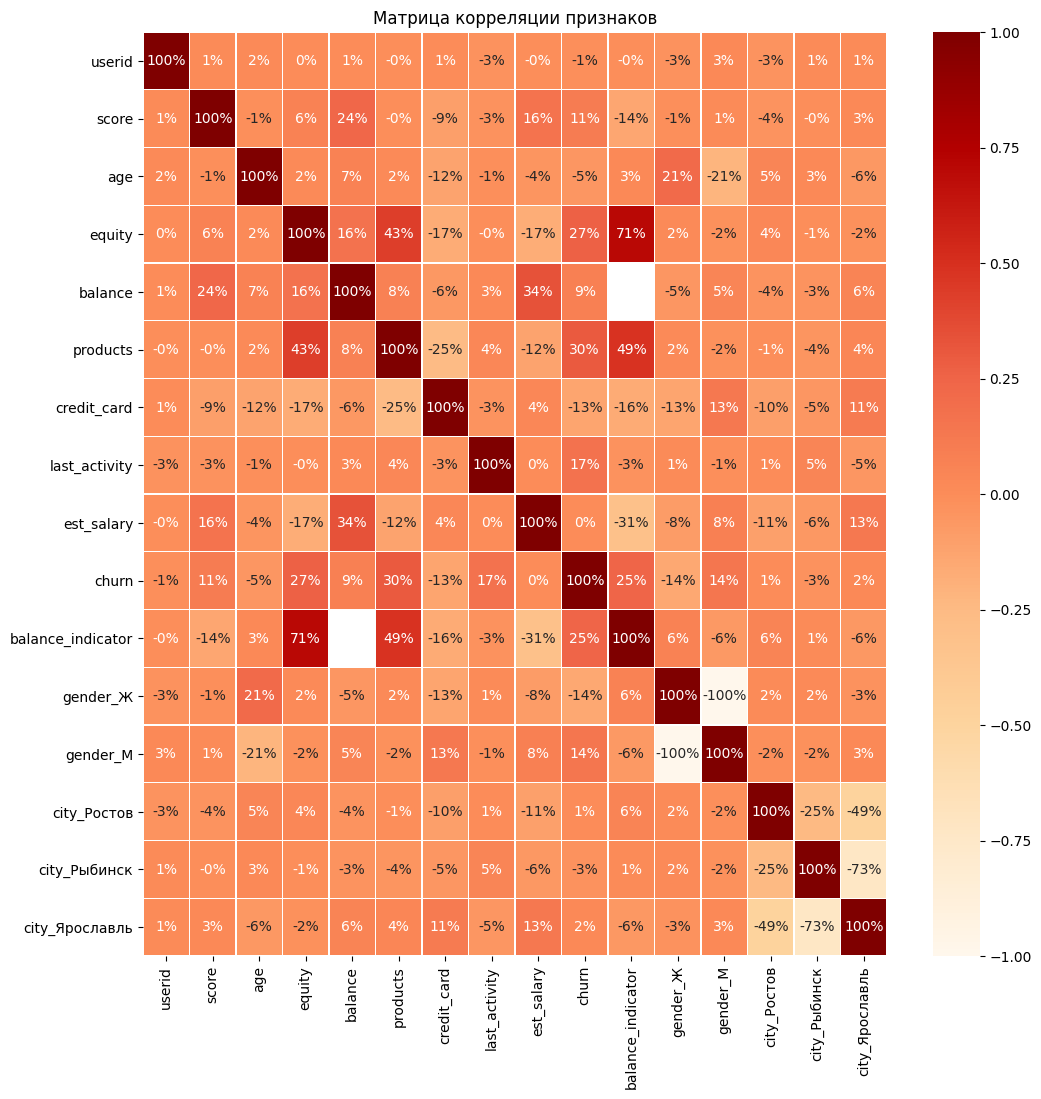

In [16]:
# сторим матрицу корреляций
corr_matrix = dfn.corr()

# визуализируем матрицу корреляций, используем тепловую карту
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, cmap="OrRd", annot=True, fmt = '.0%', linewidth=0.1)
plt.title('Матрица корреляции признаков')
plt.show()

<div style="border:solid blue 1px; padding: 10px">
Оценка влияния пропусков в данных:
    
у поля age имеется слабая корреляция с признаками gender (21%) и credit_card (-12%), с остальными признаками корреляция незначительная (менее 10%). Можно сделать вывод, что  пропуски являются случайными и не зависят от переменных (MCAR). Учитывая также незначительную долю пропусков в поле age (менее 1%), пропуски в этом поле можно удалить 
    
      
у поля balance_indicator есть высокая корреляция с признаками equity, products, т.о. пропуски в данном столбце не случайны (MNAR). Учитывая также большую долю пропусков в этом столбце (23%), удаление приведет к потере данных и искажению дальнейшего анализа.  На данном этапе пропуски остаются без изменений. 

In [17]:
# удаляем пропуски в поле age
df = df.dropna(subset = ['age'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9974 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   userid         9974 non-null   int64  
 1   score          9974 non-null   float64
 2   city           9974 non-null   object 
 3   gender         9974 non-null   object 
 4   age            9974 non-null   float64
 5   equity         9974 non-null   int64  
 6   balance        7695 non-null   float64
 7   products       9974 non-null   int64  
 8   credit_card    9974 non-null   int64  
 9   last_activity  9974 non-null   int64  
 10  est_salary     9974 non-null   float64
 11  churn          9974 non-null   int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 1013.0+ KB


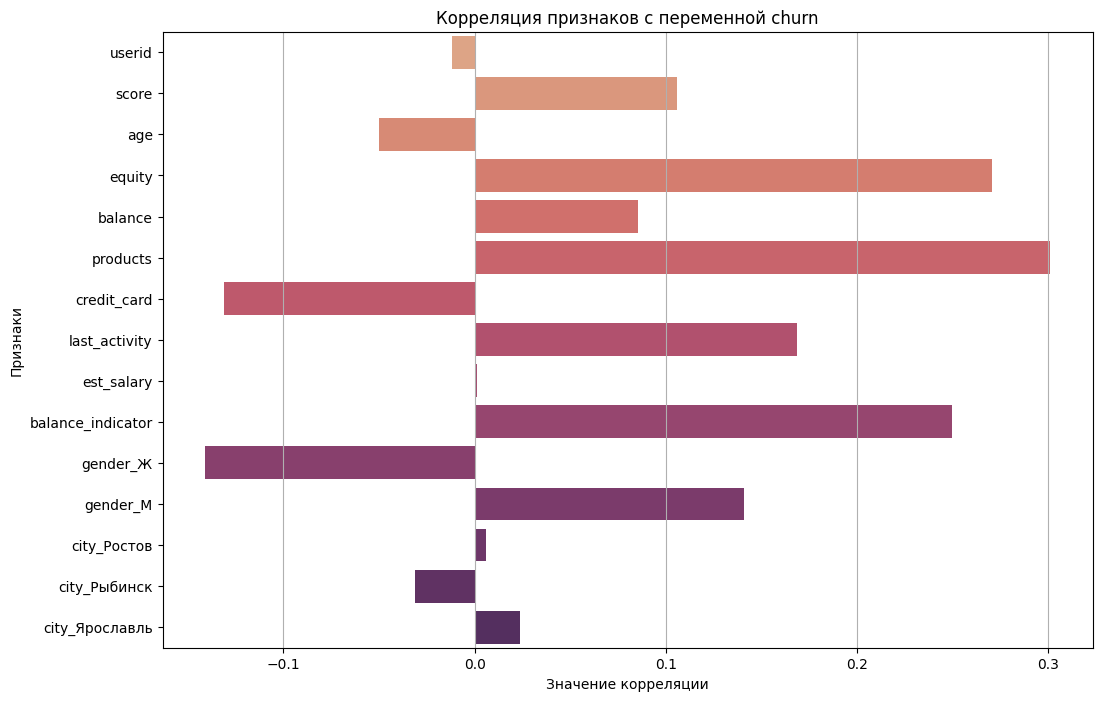

In [18]:
# корреляция столбца churn в виде отдельного графика
churn_corr = corr_matrix['churn'].drop('churn')

plt.figure(figsize=(12, 8))
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette = "flare")
plt.title('Корреляция признаков с переменной сhurn')
plt.xlabel('Значение корреляции')
plt.ylabel('Признаки')
plt.grid(axis='x')
plt.show()

<div style="border:solid blue 1px; padding: 10px">
    
Оценка корреляции  оттока с другими признаками: 
    
По шкале Чеддока корреляция оттока с каждым из признаков слабая (не более 30%)
    
наибольшая положительная корреляция у оттока с признаками: 
- количество продуктов (30%), 
- баллы собственности (27%), 
- активность клиента (17%),
- пол клиента M (14%)

наибольшая отрицательная корреляция с признаком наличия кредитной карты(-13%) и женским полом (-14%). Т.о. можно сделать вывод, что чем больше продуктов, собственности и активнее клиент, тем более вероятность оттока. И наоборот,  клиенты с кредитной картой менее склонны к оттоку. Также на отток влияет пол клиента (мужчины более склонны)

Также следует отметить положительную корреляцию у признаков: 
- количество продуктов и баллы собственности (43%) - умеренная связь
- баланс и зарплата (34%) - умеренная связь
- баланс и скоринговый балл (24%) - слабая связь

<a id="cell4.2"></a>
### Анализ распределения признаков в разрезе оттока

In [19]:
# ключевые числовые характеристики признаков
df.describe()

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn
count,9974.000000,9974.000000,9974.000000,9974.000000,7.695000e+03,9974.000000,9974.000000,9974.000000,9.974000e+03,9974.000000
mean,171755.218669,848.682575,42.734409,2.630840,8.272456e+05,1.871466,0.680168,0.522859,1.477868e+05,0.182374
std,33695.527126,65.399720,12.179971,1.979965,1.980327e+06,0.792729,0.466435,0.499502,1.392855e+05,0.386172
min,94561.000000,642.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.546300e+03,0.000000
25%,142760.000000,802.000000,33.000000,0.000000,2.956987e+05,1.000000,0.000000,0.000000,7.525166e+04,0.000000
50%,172643.000000,853.000000,40.000000,3.000000,5.242953e+05,2.000000,1.000000,1.000000,1.196268e+05,0.000000
75%,201163.750000,900.000000,51.000000,4.000000,9.800512e+05,2.000000,1.000000,1.000000,1.744998e+05,0.000000
max,229145.000000,1000.000000,86.000000,9.000000,1.191136e+08,5.000000,1.000000,1.000000,1.395064e+06,1.000000


In [20]:
# мода категориальных признаков
mode_city_0 = df.loc[df['churn']==0,'city'].mode()[0]
mode_gender_0 = df.loc[df['churn']==0,'gender'].mode()[0]
mode_city_1 = df.loc[df['churn']==1,'city'].mode()[0]
mode_gender_1 = df.loc[df['churn']==1,'gender'].mode()[0]

In [21]:
# оценка мер центральной тенденции признаков в разрезе попавших в отток и лояльных клиентов:
# для непрерывных - среднее и медиана(при наличии выбросов), для дискретных - медиана, для категориальных - мода
summary = df.groupby('churn').agg(
        средняя_зарплата=('est_salary', 'mean'),
        медиана_зарплаты=('est_salary', 'median'),
        средний_возраст=('age', 'mean'),
        средний_баланс=('balance','mean'),
        медиана_баланса=('balance','median'),
        средний_скоринговый_балл=('score','mean'),
        медиана_количества_продуктов=('products', 'median'),
        медиана_баллов_собственности=('equity', 'median'),
        средняя_активность=('last_activity','mean'),
        среднее_наличие_кредитной_карты=('credit_card','mean')
        ).T.reset_index().round(2)

summary['относительная разница,%'] = (summary[1]-summary[0])/summary[1]*100

summary.loc[10] = ['мода_пол', mode_gender_0, mode_gender_1,'NaN']
summary.loc[11] = ['мода_город', mode_city_0, mode_city_1,'NaN']

summary = summary.rename(columns={'churn':' ','index':'признак',0:'не отток',1:'отток'})
summary

churn,признак,не отток,отток,"относительная разница,%"
0,средняя_зарплата,147674.64,148289.7,0.414769
1,медиана_зарплаты,118227.6,125395.22,5.716023
2,средний_возраст,43.02,41.45,-3.787696
3,средний_баланс,733031.63,1134458.21,35.384872
4,медиана_баланса,475410.09,783908.9,39.353911
5,средний_скоринговый_балл,845.4,863.42,2.087049
6,медиана_количества_продуктов,2.0,2.0,0.0
7,медиана_баллов_собственности,3.0,4.0,25.0
8,средняя_активность,0.48,0.7,31.428571
9,среднее_наличие_кредитной_карты,0.71,0.55,-29.090909


<div style="border:solid blue 1px; padding: 10px">
    
Вывод: у клиентов, попавших в отток, следующие отличия:
- выше средние значения всех признаков, кроме возраста и наличия крединой карты
- выше медианные значения  баланса, зарплаты, баллов собственности
- реже на 29% пользуются кредитными картами
- более активны
- меньше на 4% средний возраст
- среди них больше мужчин, чем женщин
 
В обеих группах скошенное  распределение баланса и зарплаты (медиана больше среднего), т.е. есть выбросы. Больше всего клиентов из Ярославского отделения.
    
Таким образом на основании средних, медианных и моды значений признаков, можно сформировать портрет клиента, попавшего в отток:
    
    - мужчина в возрасте  41,5 лет из Ярославского отделения
    - балансовый остаток 784 тыс
    - з/п 125 тыс
    - скоринговый балл 863
    - баллов собственности 4 
    - количество продуктов 2 
   
Портрет лояльного клиента:
    
    - женщина в возрасте 43 года из Ярославского отделения
    - балансовый остаток 475 тыс
    - з/п 118 тыс
    - скоринговый балл 845
    - баллов собственности 3
    - количество продуктов 2
    
Далее признаки будут проанализированы более детально в разрезе оттока

**Все признаки можно разделить на три группы: непрерывные, категориальные и бинарные. 
Проанализируем распределение признаков по каждой группе в разрезе оттока**

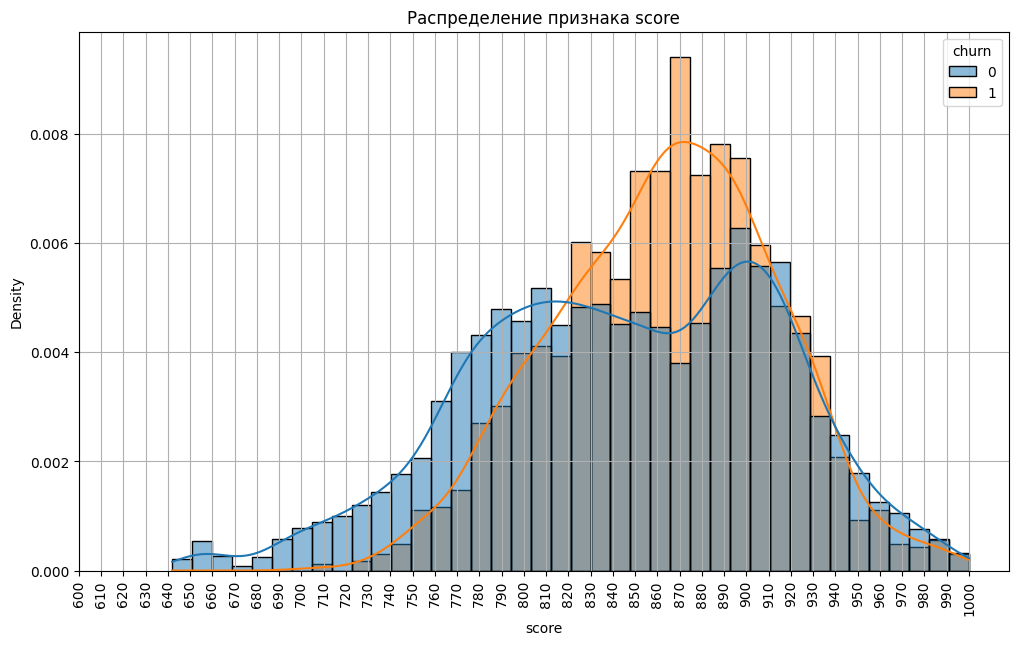

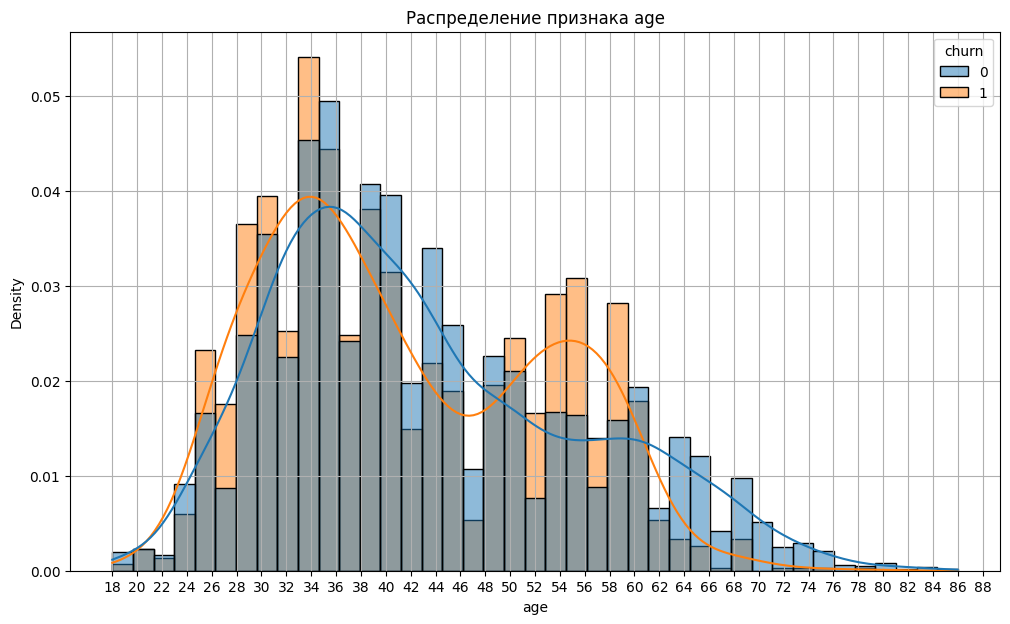

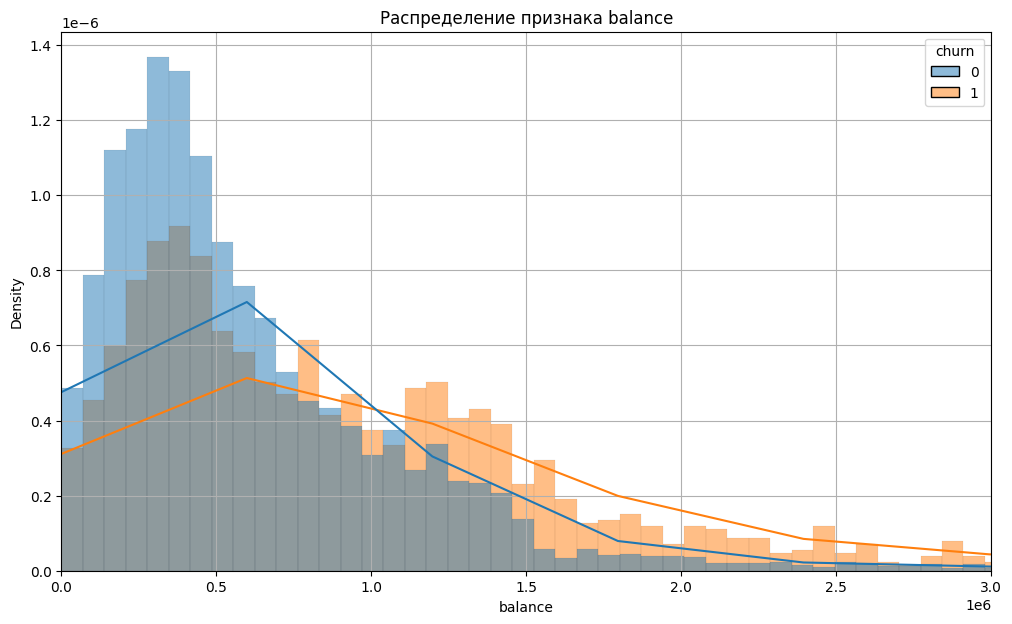

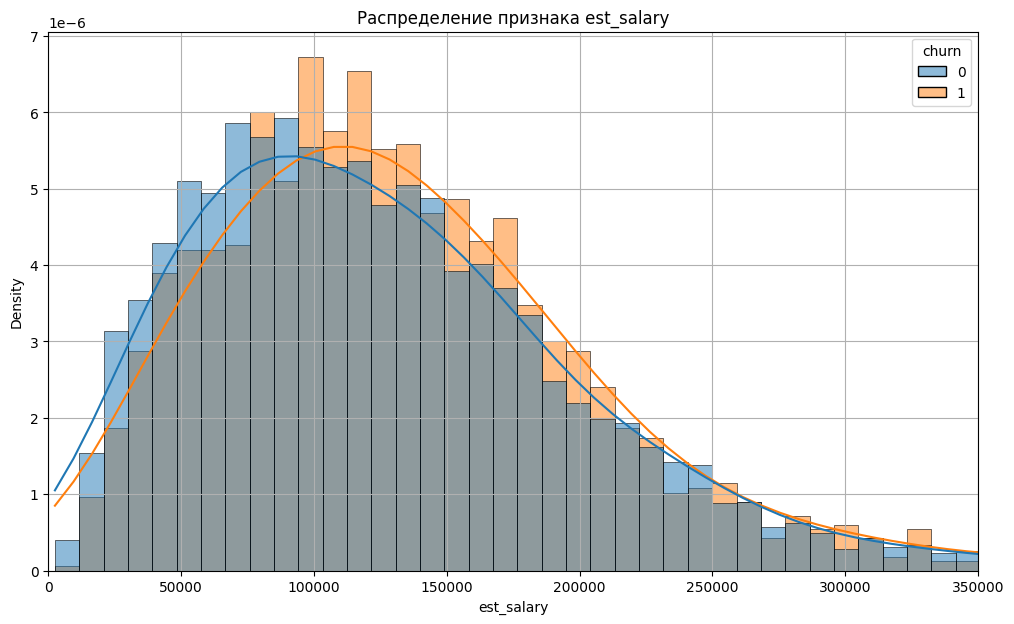

In [22]:
# непрерывные признаки
continuous_mark = ['score','age','balance','est_salary']

# строим гистограммы распределения непрерывных признаков
for mark in continuous_mark:
    plt.figure(figsize=(12, 7))
    
    sns.histplot(data=df, x=mark, common_norm=False, stat='density', hue='churn', kde=True)
    plt.title(f'Распределение признака {mark}')
    plt.grid()  

   # ограничиваем ось х 
    if mark == 'balance':
         plt.xlim(0, 3000000)
    elif mark == 'est_salary':
         plt.xlim(0, 350000)
    elif mark == 'score':
         plt.xticks(np.arange(600,1010,10),rotation = 90)
    elif mark == 'age':
         plt.xticks(np.arange(18,90,2)) 
    plt.show()


<div style="border:solid blue 1px; padding: 10px">
    
Вывод: более склонны к оттоку клиенты со следующими признаками:
- скоринговый балл 820-940 
- возраст до 35 и от 50 до 60
- баланс более 1 млн
- зарплата более 100 тыс

In [23]:
# средний отток по банку
churn_mean = df['churn'].mean()

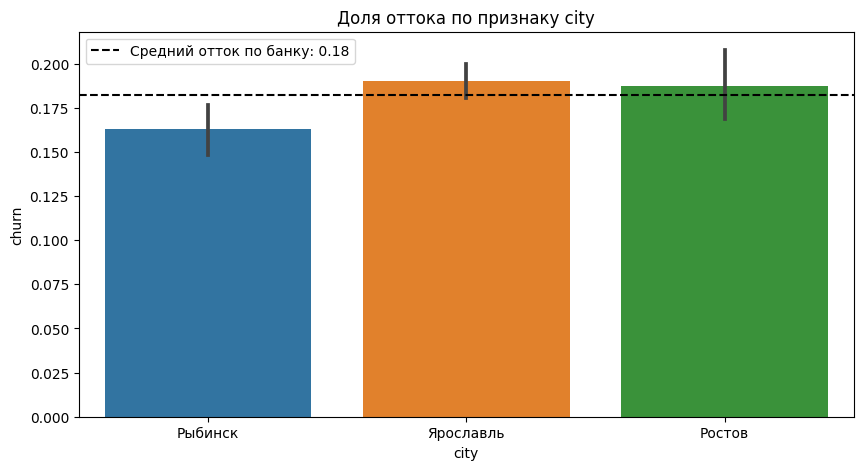

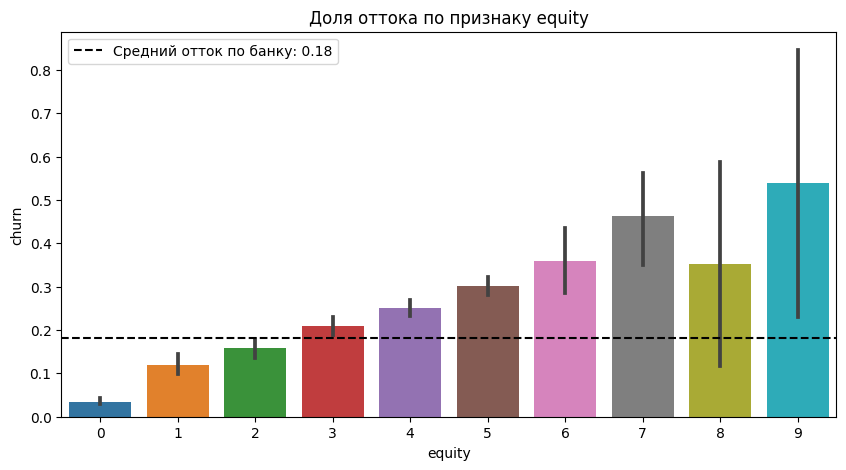

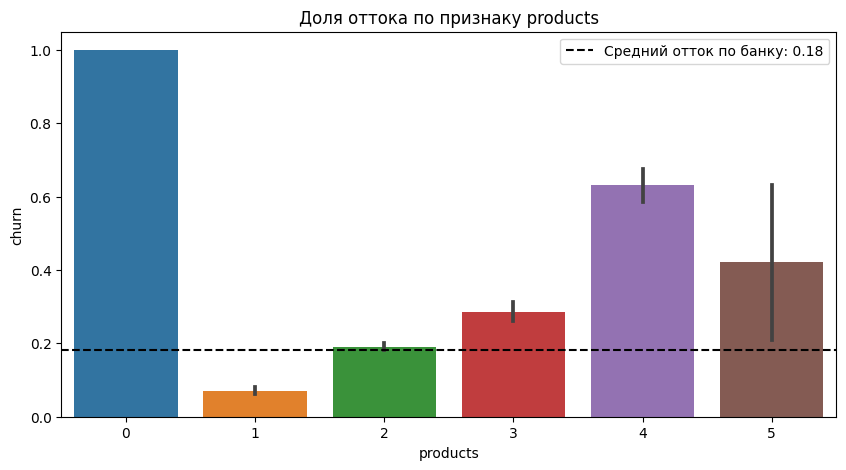

In [24]:
# строим диаграммы распределения категориальных признаков
categorical_mark = ['city','equity', 'products']

for mark in categorical_mark:
    plt.figure(figsize=(10, 5))
    
    sns.barplot(x=mark, y=df['churn'], data=df)
    plt.title(f'Доля оттока по признаку {mark}')
    plt.axhline(y=churn_mean, color='black', linestyle='--', label=f'Cредний отток по банку: {churn_mean:.2f}')
    plt.legend()
    
    plt.show()

У клиентов без продуктов самый высокий отток (1), проанализируем отдельно данных клиентов

In [25]:
df.loc[(df['products']==0)]

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
8957,147837,962.0,Рыбинск,Ж,79.0,3,NaN,0,0,0,25063.96,1


всего 1 клиент без продуктов, который попал в отток, данного клиента можно не учитывать при сегментации, т.о. рассматривать только клиентов с продуками 

<div style="border:solid blue 1px; padding: 10px">
    
Вывод: более склонны к оттоку клиенты со следующими признаками:
- Ярославского и Ростовского отделения
- количество баллов собственности 3 и более
- количество продуктов 3 и более


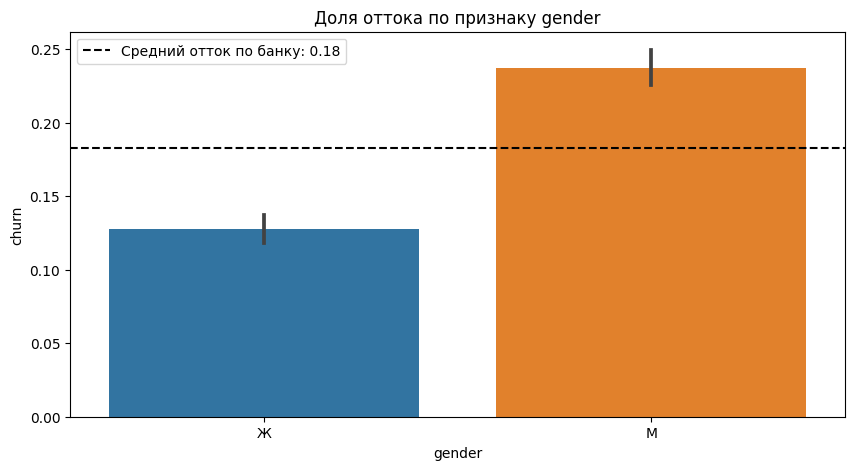

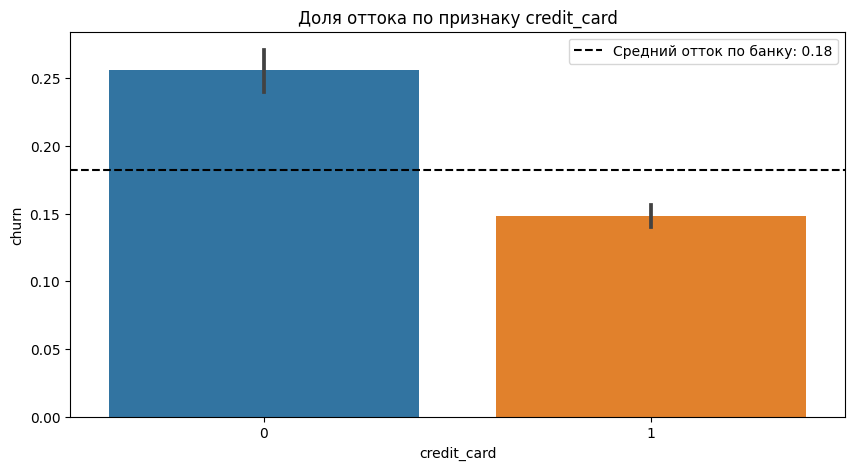

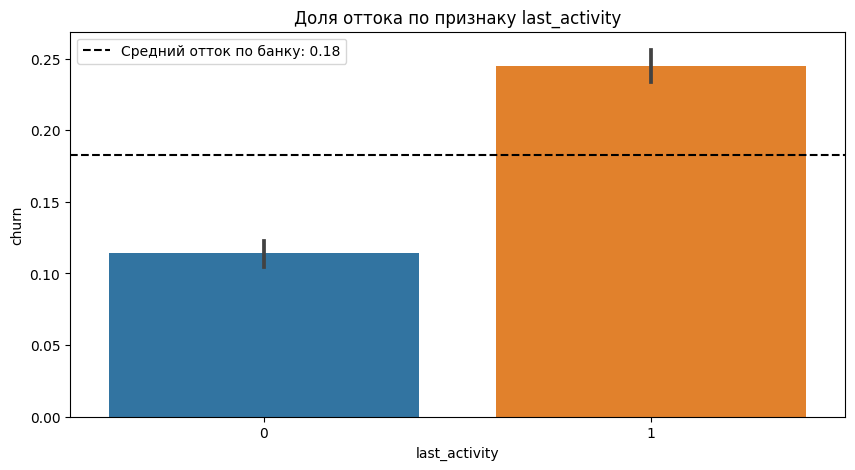

In [26]:
# строим диаграммы распределения бинарных признаков
binary_mark = ['gender', 'credit_card', 'last_activity']

for mark in binary_mark:
    plt.figure(figsize=(10, 5))
    
    sns.barplot(x=mark, y=df['churn'], data=df)
    plt.title(f'Доля оттока по признаку {mark}')
    plt.axhline(y=churn_mean, color='black', linestyle='--', label=f'Cредний отток по банку: {churn_mean:.2f}')
    plt.legend()
    
    plt.show()

<div style="border:solid blue 1px; padding: 10px">
    
Вывод: более склонны к оттоку клиенты со следующими признаками:

- мужчины
- без кредитов
- активные


<a id="cell4.3"></a>
### Категоризация клиентов

**Для более точной оценки непрерывных признаков и сравнения оттока со средним уровнем по банку проведем  категоризацию.**  
<a id="cell4.3.1"></a>
#### Категоризация клиентов в зависимости от остатка средств на балансе

In [27]:
def categorize_balance(balance):
    """Функция категоризирует клиентов в зависимости от остатка средств на балансе,
         принимает 1 аргумент - значение баланса, возвращает категорию клиента"""
    try:
        if balance <= 1000000:
            return 'medium'
        elif 1000001 <= balance: 
            return 'high'
    except:
        pass

# добавляем новый столбец с категоризацией
df["balance_status"] = df['balance'].apply(categorize_balance)   

# проверяем распределение клиентов по категориям
df['balance_status'].value_counts()

medium    5822
high      1873
Name: balance_status, dtype: int64

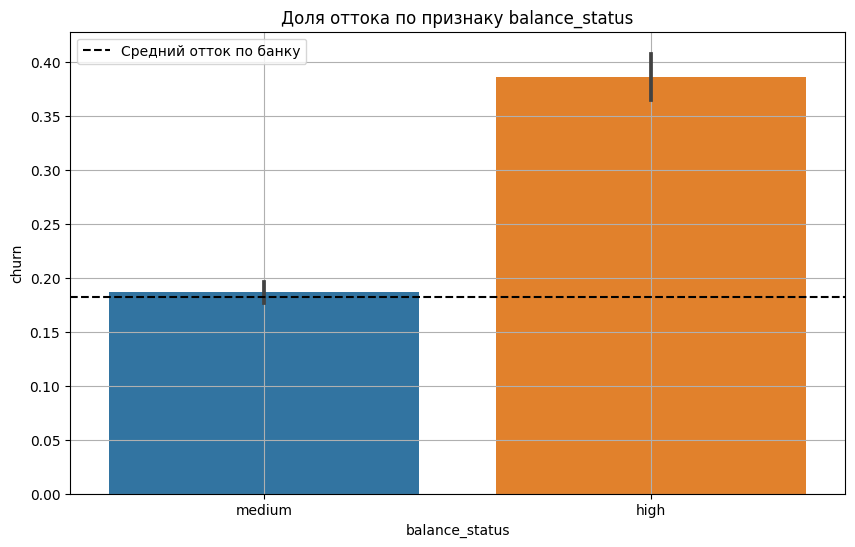

In [28]:
# визуализируем получившиеся категории в разрезе оттока
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='balance_status', y='churn')
plt.title('Доля оттока по признаку balance_status')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Выше среднего отток у клиентов c остатком на балансе более 1 млн. тыс руб. 

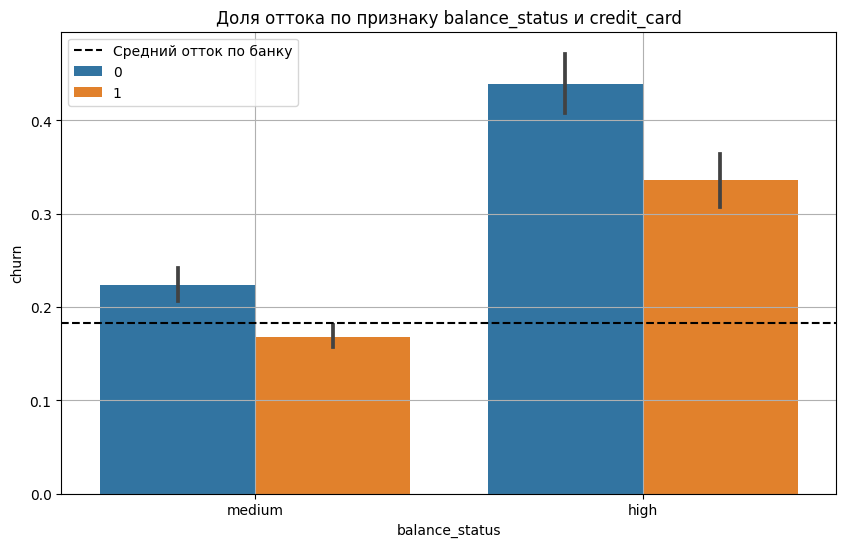

In [29]:
# дополнительно проверим отток в разрезе баланса и наличия кредита

plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='balance_status', y='churn', hue ='credit_card')
plt.title('Доля оттока по признаку balance_status и credit_card')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Во всех категориях доля оттока у клиентов без кредитов выше, чем у клиентов с кредитами

<a id="cell4.3.2"></a>
#### Категоризация клиентов в зависимости от возраста

In [30]:
def categorize_age(age):
    """Функция категоризирует клиентов в зависимости от возраста,
         принимает 1 аргумент - значение возраста, возвращает категорию клиента"""
    try:
        if age <= 35:
            return 'young'
        elif 36 <= age <= 50:
            return 'medium'
        elif 51 <= age <= 59:
            return 'old'
        elif age >= 60:
            return 'old +'
    except:
        pass

# добавляем новый столбец с категоризацией
df["age_status"] = df['age'].apply(categorize_age)   

# проверяем распределение клиентов по категориям
df['age_status'].value_counts()

medium    4072
young     3291
old       1410
old +     1201
Name: age_status, dtype: int64

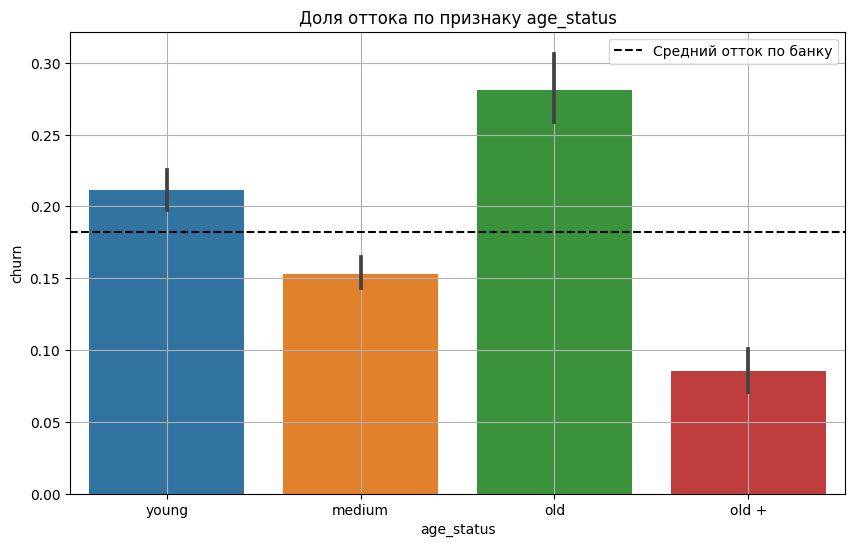

In [31]:
# визуализируем получившиеся категории в разрезе оттока 
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='age_status', y='churn')
plt.title('Доля оттока по признаку age_status')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Повышенный отток у людей в возрасте до 35 (young) и 50-60 лет (old)

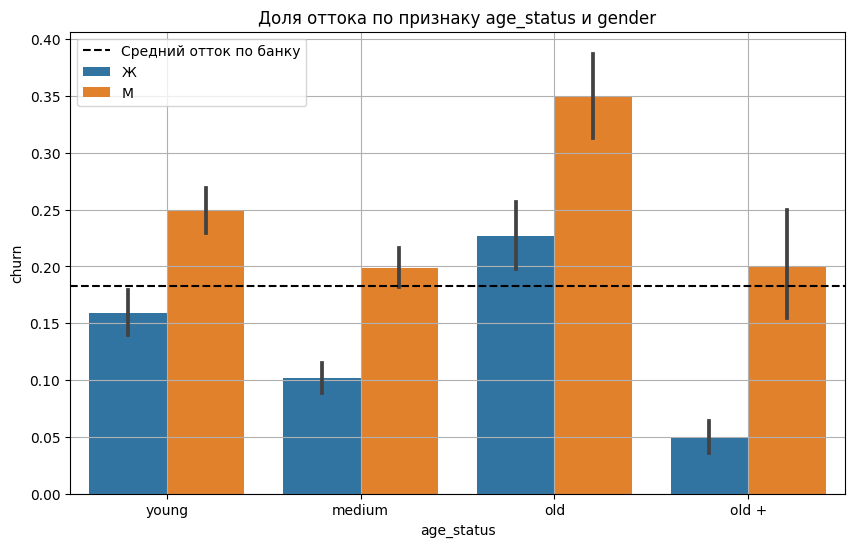

In [32]:
# дополнительно проверим отток в разрезе возраста и пола
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='age_status', y='churn', hue='gender')
plt.title('Доля оттока по признаку age_status и gender')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Мужчины всех возрастных категорий более склонны к оттоку, чем женщины. Выше среднего  отток у мужчин всех возрастных категорий. У женщин выше среднего только в группе old (50-60 лет).

<a id="cell4.3.3"></a>
#### Категоризация клиентов по score

In [33]:
def categorize_score(score):
    """Функция категоризирует клиентов в зависимости от скорингового балла,
         принимает 1 аргумент - значение скорингового балла, возвращает категорию клиента"""
    try:
        if score <= 820:
            return 'low'
        elif 821 <= score <= 940:
            return 'medium '
        elif score >= 941:
            return 'high'
    except:
        pass

# добавляем новый столбец с категоризацией
df["score_status"] = df['score'].apply(categorize_score)   



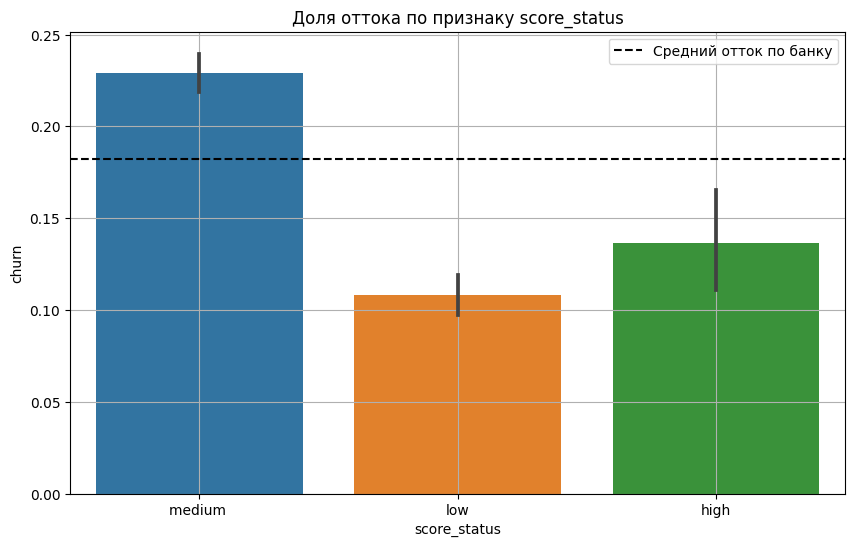

In [34]:
# визуализируем получившиеся категории в разрезе score
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='score_status', y='churn')
plt.title('Доля оттока по признаку score_status')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Клиенты со скоринговым баллом от 820 до 940 более склонны к оттоку (уровень оттока выше среднего)

<a id="cell4.3.4"></a>
#### Категоризация клиентов по уровню зарплаты

In [35]:
def categorize_salary(salary):
    """Функция категоризирует клиентов в зависимости от уровня з/п,
         принимает 1 аргумент - значение з/п, возвращает категорию клиента"""
    try:
        if salary <= 100000:
            return 'low'
        else:
            return 'high'
    except:
        pass

# добавляем новый столбец с категоризацией
df["salary_status"] = df['est_salary'].apply(categorize_salary)   

# проверяем распределение клиентов по категориям
df['salary_status'].value_counts()

high    6049
low     3925
Name: salary_status, dtype: int64

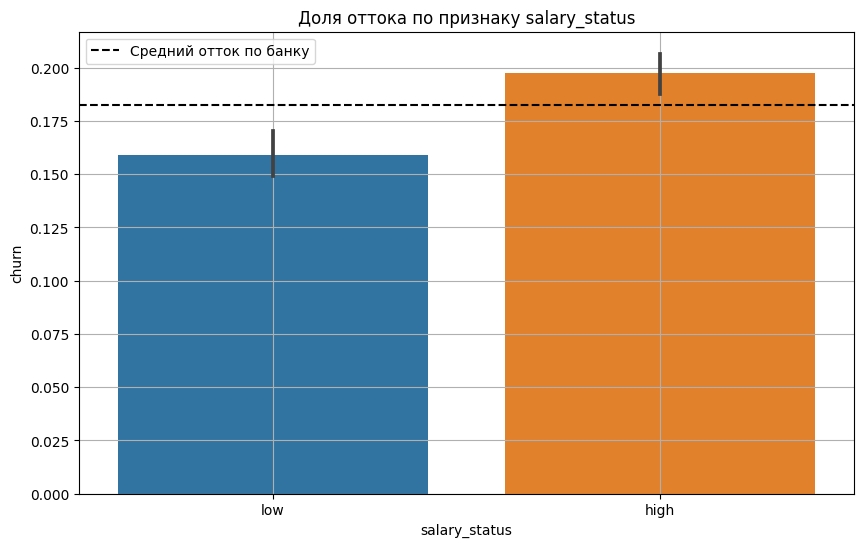

In [36]:
# визуализируем получившиеся категории в разрезе salary
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='salary_status', y='churn')
plt.title('Доля оттока по признаку salary_status')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Уровень оттока выше среднего у клиентов с з/п от 100 тыс

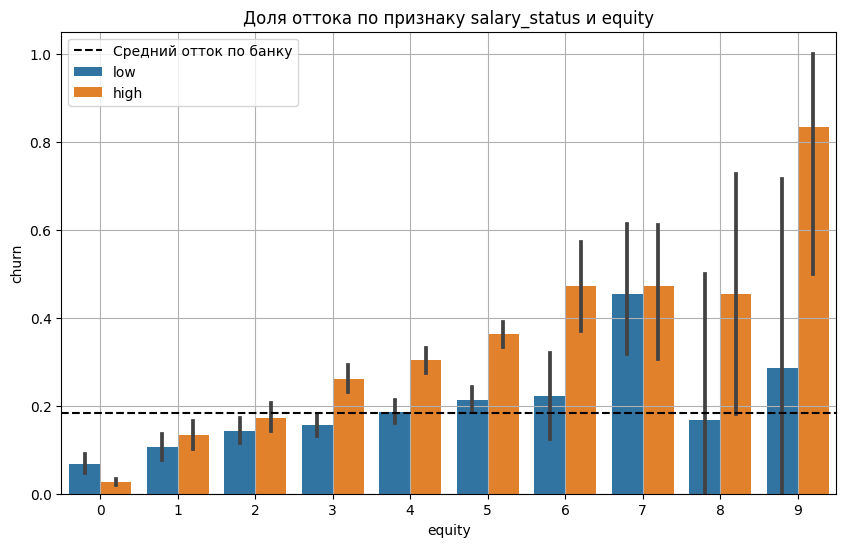

In [37]:
# дополнительно проверим отток в разрезе з/п и собственности
plt.figure(figsize=(10, 6))
    
sns.barplot(data=df, x='equity', y='churn', hue='salary_status')
plt.title('Доля оттока по признаку salary_status и equity')
plt.axhline(y=churn_mean, color='black', linestyle='--', label='Cредний отток по банку')
plt.legend()
plt.grid()  
         
plt.show()

Выше среднего отток у клиентов с зарплатой high (более 100 тыс.) и баллами собственности 3 и более

<div style="border:solid blue 1px; padding: 10px">

**Вывод по разделу:** 
    
На основании проведенного анализа данных можно выделить следующие категории клиентов, более склонных к оттоку (уровень оттока выше среднего по банку):
    
- активные,
- количество баллов собственности 3 и более,
- количество продуктов 3 и более,
- без кредитной карты,
- c остатком на балансе более 1 млн. руб.,
- в возрасте до 35 (young) и 50-60 лет (old),
- со скоринговым баллом от 820 до 940,
- имеющие з/п от 100 тыс.,
- мужчины всех возрастных категорий более склонны к оттоку, чем женщины
 
    

<a id="cell5"></a>
## Проверка гипотез

<a id="cell5.1"></a>
### Гипотеза о разнице средних зарплат 
H0: Средняя зарплата клиентов, попавших в отток =  средней зарплате лояльных клиентов

H1: Средняя зарплата клиентов, попавших в отток не равна средней зарплате лояльных клиентов

In [38]:
# формируем выборки

sample_1 = df.loc[df['churn']==1,'est_salary'].tolist() # клиенты, попавшие в отток
sample_0 = df.loc[df['churn']==0,'est_salary'].tolist() # лояльные клиенты

# размеры выборок
print(len(sample_1))
print(len(sample_0))

# дисперсии выборок
print(f'Диспесия sample_1 = {np.var(sample_1)}')
print(f'Диспесия sample_0 = {np.var(sample_0)}')
print(f'Разница дисперсий = {np.var(sample_0)/np.var(sample_1)-1}')

1819
8155
Диспесия sample_1 = 15104008500.895664
Диспесия sample_0 = 20356342952.421223
Разница дисперсий = 0.34774440515006977


Несмотря на то, что дисперсии различаются (более чем на 25%), дополнительно проверим равенство дисперсий в обеих выборках критерием Левене, чтобы подтвердить статистическую значимость различий

H0: дисперсии равны 
H1: дисперсии не равны

уровень значимости = 0,05

In [39]:
# проверка равенства дисперсий в обеих выборках критерием Левене

results_levene = st.levene(sample_1, sample_0)
print(results_levene)

if results_levene[1] < 0.05:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

LeveneResult(statistic=6.633998310519049, pvalue=0.010019310207766953)
Отвергаем нулевую гипотезу


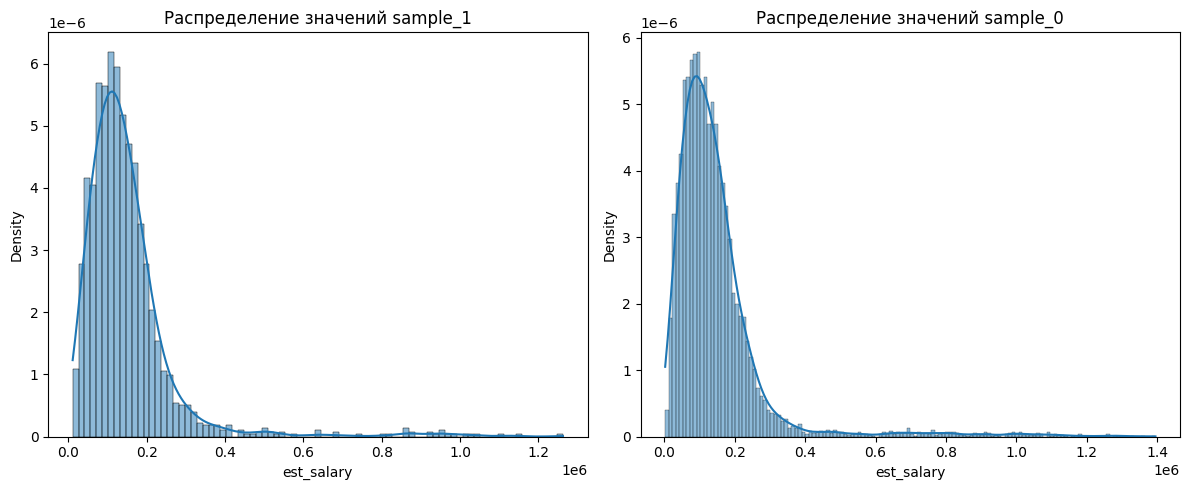

In [40]:
# проверим распределение значений в обеих выборках

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(x=sample_1, ax=ax1, common_norm=False, stat='density', kde=True)
ax1.set_title('Распределение значений sample_1')
ax1.set_xlabel('est_salary')
plt.grid()

sns.histplot(x=sample_0, ax=ax2, common_norm=False, stat='density',  kde=True)
ax2.set_title('Распределение значений sample_0')
ax2.set_xlabel('est_salary')
plt.grid()

plt.tight_layout()
plt.show()

Распределение данных в обеих выборках сильно скошено, обе выборки имеют длинные правые "хвосты", т.е. есть выбросы (клиенты с высокими зарплатами). 

Учитывая ненормальное распределение данных в обеих выборках, наличие выбросов используем тест Манна-Уитни для проверки гипотезы

In [41]:
print('Средняя зарплата клиентов, попавших в отток:', sum(sample_1)/len(sample_1))
print('Средняя зарплата лояльных клиентов:', sum(sample_0)/len(sample_0))

alpha = 0.05 # уровень статистической значимости

results = st.mannwhitneyu(sample_1, sample_0)

print('p-значение: ', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, разница не является статистически значимой')
    

Средняя зарплата клиентов, попавших в отток: 148289.70222100036
Средняя зарплата лояльных клиентов: 147674.63788105454
p-значение:  0.0001941125216825749
Отвергаем нулевую гипотезу: разница статистически значима


<a id="cell5.2"></a>
### Гипотеза о равенстве доли оттока у клиентов с разной зарплатой
H0: уровень оттока у клиентов с зарплатой более 100 тыс = уровень оттока у клиентов с зарплатой менее 100 тыс.

H1: уровень оттока у клиентов с зарплатой более 100 тыс. не равен уровень оттока у клиентов с зарплатой менее 100 тыс.

In [42]:
# формируем выборки
df_high = df.loc[df['salary_status'] != 'low','churn'].tolist()
df_low = df.loc[df['salary_status'] == 'low','churn'].tolist()

print(len(df_high))
len(df_low)


6049


3925

In [43]:
# считаем отток в каждой группе 
high_churn = sum(df_high)
high_total = len(df_high)
print('Отток с з/п >100 тыс.:', high_churn/high_total)

low_churn = sum(df_low)
low_total = len(df_low)
print('Отток с з/п <100 тыс.:', low_churn/low_total)


Отток с з/п >100 тыс.: 0.19738799801620102
Отток с з/п <100 тыс.: 0.1592356687898089


In [44]:
stat_salary, p_value_salary = proportions_ztest([high_churn, low_churn],[high_total, low_total])

alpha = .05 
print('p-значение: ', p_value_salary)

if p_value_salary < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение:  1.4322322168344113e-06
Отвергаем нулевую гипотезу


Разницу в уровне оттока клиентов с з/п >100 тыс. и клиентов с з/п менее 100 тыс. считаем статистически значимой.

<a id="cell6"></a>
## Сегментация клиентов

**На основании проведенного анализа данных можно выделить следующие группы клиентов, более склонных к оттоку (уровень оттока выше среднего по банку)**

Группа: Клиенты с денежными средствами и без кредитов (баланс более 1 млн, нет кредитной карты). 

In [45]:
group_rich = df.loc[(df['balance']>1000000)&(df['credit_card']==0)]
print('Количество клиентов в группе:', group_rich.shape[0])
print('Количество отточных клиентов в группе:', group_rich.loc[group_rich['churn']==1,'churn'].count())
print ('Cредний отток по группе:', group_rich['churn'].mean())

Количество клиентов в группе: 899
Количество отточных клиентов в группе: 395
Cредний отток по группе: 0.43937708565072303


Рекомендации по удержанию клиентов группы: 

- делать акцент на  премиальном статусе (VIP-статусе и т.п.)  клиентов этой группы. Помимо психологического аспекта (самого факта принадлежности клиента к категории VIP), данный статус должен давать более выгодные условия по продуктам банка, например повышенные ставки по депозитам и накопительным счетам (если сумма  депозита или остаток по балансу более 700 тыс), повышенный кэшбек и т.д. 

- предоставлять персонального менеджера для консультирования по другим продуктам банка, возможность индивидуального  дизайна карты, возможность посещения бизнес-залов в аэропортах и т.д.

- предлагать инвестиционные продукты банка

- делать акцент на повышении кредитования в группе: понижать ставку по кредиту и/или увеличивать грейс-период в зависимости от остатка по балансу, предварительно рассчитывать сумму на основании остатка по балансу и информировать клиентов о предодобренном кредите.

Группа: Мужчины в возрасте от 50 до 60 лет

In [46]:
group_oldman = df.loc[(df['age']>50)&(df['age']<=60)&(df['gender']=="М")]
print('Количество клиентов в группе:', group_oldman.shape[0])
print('Количество отточных клиентов в группе:', group_oldman.loc[group_oldman['churn']==1,'churn'].count())
print ('Cредний отток по группе:', group_oldman['churn'].mean())

Количество клиентов в группе: 681
Количество отточных клиентов в группе: 236
Cредний отток по группе: 0.3465491923641703


Рекомендации по удержанию клиентов группы: 

- распространить льготные условия по продуктам банка для пенсионеров на эту категорию.  Примеры льготных условий: карты с бесплатным обслуживанием, сниженные комиссии за переводы
- предлагать переводить накопительную часть пенсии в НПФ банка (предоставлять дополнительные льготы для этой категории клиентов)


Группа: Активные клиенты с большим количеством продуктов (3 и более)

In [47]:
group_active = df.loc[(df['products']>=3)&(df['last_activity']==1)]
print('Количество клиентов в группе:', group_active.shape[0])
print('Количество отточных клиентов в группе:', group_active.loc[group_active['churn']==1,'churn'].count())
print ('Cредний отток по группе:', group_active['churn'].mean())

Количество клиентов в группе: 823
Количество отточных клиентов в группе: 391
Cредний отток по группе: 0.47509113001215064


Рекомендации по удержанию клиентов группы: 
- акцент на более выгодных условиях по продуктам банка в зависимости от активности клиента, например переменные ставки по депозитам и накопительным счетам и/или повышенный кэшбек и/или увеличенный грейс-период по кредитной карте в зависимости от среднемесячного оборота по карте (чем больше клиент тратит, тем выгоднее условия)
- акцент на кросс-продажах, т.е. при оформлении 3-х и более продуктов банка, больше льгот на другие продукты

Группа: Клиенты с зарплатой больше 100 тыс и 3-мя и более баллами собственности

In [48]:
group_equity = df.loc[(df['equity']>=3)&(df['last_activity']==1)]
print('Количество клиентов в группе:', group_equity.shape[0])
print('Количество отточных клиентов в группе:', group_equity.loc[group_equity['churn']==1,'churn'].count())
print ('Cредний отток по группе:', group_equity['churn'].mean())

Количество клиентов в группе: 2920
Количество отточных клиентов в группе: 1068
Cредний отток по группе: 0.36575342465753424


Рекомендации по удержанию клиентов группы: 
- делать акцент на кредитовании под залог имущества (упрощать выдачу, предварительно рассчитывать сумму на основании остатка по балансу, з/п), информировать клиентов о предодобренном кредите
- акцент на оформление зарплатных карт, льготы для оформивших (например повышенный кэшбек, увеличенная ставка по депозитам)


<a id="cell6.1"></a>
### Приоритизация сегментов

Приоритизация сегментов проводится по двум критериям: 1. уровень оттока и 2. охват (чем больше отток и охват, тем приоритетнее).\
Проранжируем группы по убыванию приоритета :

1. Группа: Клиенты с денежными средствами и без кредитов
2. Группа: Клиенты с обеспечением с зарплатой выше среднего
3. Группа: Активные клиенты с большим количеством продуктов
4. Группа: Мужчины от 50 до 60

<a id="cell7"></a>
## Сводный вывод по проекту

<div style="border:solid blue 1px; padding: 10px">

В рамках проекта были выполнены следующие задачи:
- проведена  предобработка данных,
- проведен исследовательский анализ, в рамках проанализированы все признаки в разрезе оттока, которого выявлены признаки, влияющие на отток и сформированы портреты клиентов, склонных к оттоку
- проверены статистические гипотезы : 
    - о различии  дохода между теми клиентами, которые ушли и теми, которые остались
    - о различии доли оттока у клиентов различных зарплатных групп
    - о различии доли оттока у клиентов Ярославского и Рыбинского отделений
- сформированы и приоритизированы сегменты клиентов, наиболее склонных к оттоку
- разработаны рекомендации по удержанию клиентов данных сегментов
- подготовлена презентация для отдела маркетинга 

Основные выводы 
1. Оценка корреляции признаков показала, что 
наибольшая положительная корреляция у оттока с признаками: 
- количество продуктов (30%), 
- баллы собственности (27%), 
- активность клиента (17%),
- пол клиента M (14%) 

наибольшая отрицательная корреляция с признаком наличия кредитной карты(-13%) и женским полом (-14%). 

2. На основании проведенного анализа выделены следующие категории клиентов, более склонных к оттоку (уровень оттока выше среднего по банку):

- активные,
- количество баллов собственности 3 и более,
- количество продуктов 3 и более,
- без кредитной карты,
- c остатком на балансе более 1 млн руб.,
- в возрасте до 35 (young) и 50-60 лет (old),
- со скоринговым баллом от 820 до 940 ,
- имеющие з/п свыше 100 тыс.,
- мужчины всех возрастных категорий более склонны к оттоку, чем женщины

3. Выделены следующие группы клиентов, наиболее склонных к оттоку (приоритет в порядке убывания в зависимости от уровня оттока и размера группы):
    1. Группа: Клиенты с денежными средствами и без кредитов
    2. Группа: Клиенты с обеспечением с зарплатой выше среднего
    3. Группа: Активные клиенты с большим количеством продуктов
    4. Группа: Мужчины от 50 до 60